# Clustering am Beispiel k-Means

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.utils import shuffle

Der verwendete Datensatz ist ein synthetisch erzeugter Beispieldatensatz, der speziell für die Demonstration von *k-Means* erstellt wurde. Er enthält zweidimensionale Datenpunkte mit den Merkmalen `x` und `y`, die räumlich in drei klar abgegrenzte Gruppen angeordnet sind. Um die erzielten Ergebnisse überprüfen zu können, enthält der Datensatz zusätzlich die Spalte `cluster`, welche die bei der Datenerzeugung festgelegte Cluster-Zugehörigkeit (1, 2 oder 3) der einzelnen Datenpunkte angibt. Diese Information wird nicht für das Training des k-Means-Algorithmus verwendet, sondern dient ausschließlich der nachträglichen Auswertung und Veranschaulichung der Ergebnisse. In realen Anwendungsfällen des unsupervised Learning steht eine solche Spalte in der Regel nicht zur Verfügung, da die zugrunde liegende Struktur der Daten unbekannt ist.

In [2]:
data = pd.read_csv('kmeans_blobs.csv')
data.head()

,ID,x,y,cluster
0,0,24.412,32.932,2
1,1,35.190,12.189,1
2,2,26.288,41.718,2
3,3,0.376,15.506,0
4,4,26.116,3.963,1


Visualisierung der Datenpunkte mithilfe eines Scatter-Plots. Grundlage bilden `x` und `y`. Mithilfe der Spalte `cluster` kann die Plot-Funktion die Datenpunkte unterschiedlich einfärben.

**Hinweis**: Üblicherweise hat man zu diesem Zeitpunkt des Projektes noch keine Cluster-Informationen. Das ist dem Demo-Charakter des Datasets geschuldet (siehe oben).

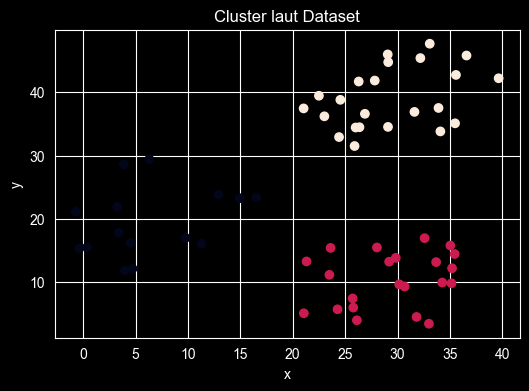

In [3]:
# Plot 1
plt.figure(figsize=(6, 4))
plt.scatter(data["x"], data["y"], c=data["cluster"])
plt.title("Cluster laut Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Daten für das Training des k-Means-Algorithmus in `X` bereitstellen. Die Punkte sind eindeutig mit den Features `x` und `y` beschrieben.

In [4]:
X = data[['x', 'y']].values
X[:5]

array([[24.412, 32.932],
       [35.19 , 12.189],
       [26.288, 41.718],
       [ 0.376, 15.506],
       [26.116,  3.963]])

## Initialisierung und Training des Modells

- Mit `KMeans(n_clusters=3, random_state=42)` wird ein k-Means-Modell erzeugt, das die Daten in drei Cluster (k=3) aufteilen soll.
Der bereits bekannte Parameter `random_state` sorgt dafür, dass die zufällige Initialisierung der Cluster-Zentren reproduzierbar ist.

- `fit(X)` trainiert das Modell auf den Merkmalsdaten `X`.
Dabei werden die Cluster-Zentren iterativ so angepasst, dass die *Inertia* (Summe der quadrierten Abstände der Punkte zu ihren jeweiligen Zentren) minimiert wird. Die *Inertia* (Cluster-Streuung) fungiert als Zielfunktion des k-Means-Algorithmus und wird im Trainingsprozess minimiert.

In [5]:
model = KMeans(n_clusters=3, random_state=42) 
model.fit(X)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


`model.labels_` enthält das Ergebnis des k-Means-Clustering.`Es handelt sich um einen Vektor, in dem jeder Eintrag genau einem Datenpunkt im ursprünglichen Datensatz entspricht.

- Der Index eines Eintrags entspricht der Zeile im Datensatz
- Der Wert (0, 1 oder 2) ist die Cluster-ID, die k-Means diesem Punkt zugewiesen hat

> **Wichtig**: Punkte mit derselben Zahl gehören zum selben Cluster, unabhängig davon, welche konkrete Zahl verwendet wird. Die Ausgabe beschreibt somit die vom Algorithmus gefundene Gruppierung der Datenpunkte, nicht deren ursprüngliche oder „wahre“ Klassen in `cluster`.

In [6]:
model.labels_

array([1, 2, 1, 0, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, 0, 0, 2, 2, 0, 1, 0, 2,
       0, 1, 0, 2, 0, 1, 0, 1, 2, 2, 2, 1, 0, 2, 1, 1, 1, 0, 2, 1, 0, 0,
       2, 1, 2, 2, 1, 2, 0, 2, 0, 1, 1, 2, 1, 1, 2, 2], dtype=int32)

Visualisierung der Datenpunkte mit farblicher Kennzeichnung der vom *k-Means*-Algorithmus ermittelten Cluster-Zugehörigkeit. Jeder Punkt wird anhand der in `model.labels_` gespeicherten Cluster-ID (0, 1 oder 2) eingefärbt, sodass Punkte mit gleicher Farbe demselben Cluster angehören.

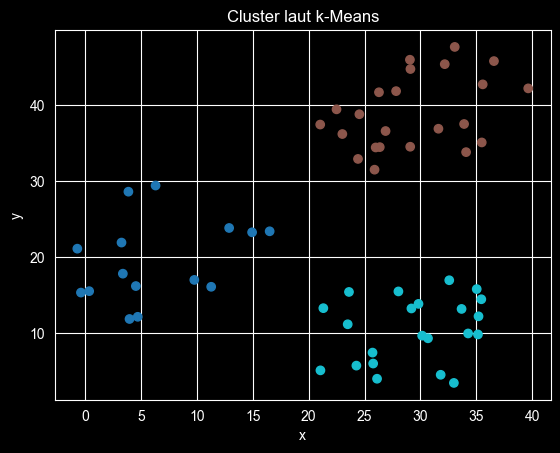

In [7]:
# Plot 2
plt.scatter(data["x"], data["y"], c=model.labels_, cmap="tab10")
plt.title("Cluster laut k-Means")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Das Zentrum des jeweiligen Cliusters ist über `model.cluster_centers_` einsehbar. 

In [8]:
print(model.cluster_centers_)

[[ 6.32286667 19.5598    ]
 [29.30495652 39.05078261]
 [29.33086364 10.43240909]]


Ergänzung des *Plots 2* (siehe oben) um die 3 Zentren des jeweiligen Clusters.

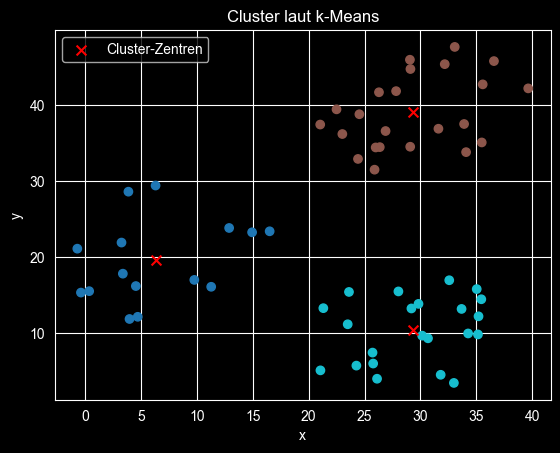

In [9]:
plt.scatter(data["x"], data["y"], c=model.labels_, cmap="tab10")

# Cluster-Zentren
centers = model.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="red",
    marker="x",
    s=50,
    label="Cluster-Zentren"
)

plt.title("Cluster laut k-Means")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


## Die Auswahl von k

Eine Möglichkeit stellt die *Ellbow*-Methode dar. Hierbei handelt es sich um eine visuelle Methode, um eine sinnvolle Anzahl von Clustern 𝑘 für k-Means abzuschätzen. Dazu wird das Modell für verschiedene Werte von 𝑘 trainiert und jeweils die Inertia berechnet, also die Summe der quadrierten Abstände der Datenpunkte zu ihren Cluster-Zentren. Mit wachsendem 𝑘 nimmt die Inertia stets ab, da die Daten feiner aufgeteilt werden. In der grafischen Darstellung zeigt sich häufig ein Punkt, ab dem zusätzliche Cluster nur noch geringe Verbesserungen bringen. Dieser „Knick“ (Elbow) kennzeichnet einen sinnvollen Kompromiss zwischen Clusterqualität und Modellkomplexität. Die Elbow-Methode liefert damit eine heuristische Orientierung, jedoch keine eindeutige mathematische Entscheidung. 

Liefert die Elbow-Methode keinen eindeutig Knick, kann man quantitative Bewertungsmaße, wie bspw. Silhouette-Score, einsetzen. Siehe hierzu `from sklearn.metrics import silhouette_score`.

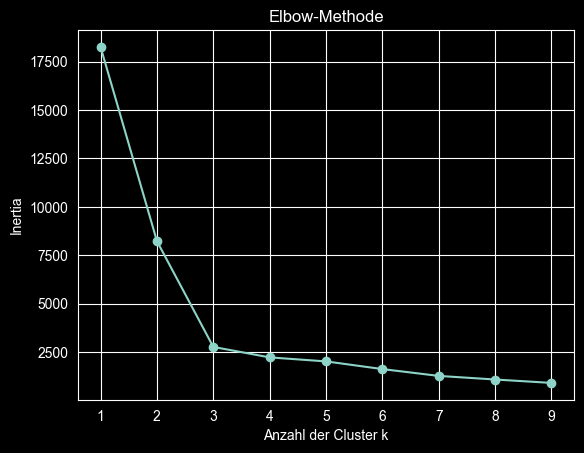

In [10]:
inertias = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(range(1, 10), inertias, marker="o")
plt.xlabel("Anzahl der Cluster k")
plt.ylabel("Inertia")
plt.title("Elbow-Methode")
plt.show()
